In [ ]:
import pandas as pd


In [ ]:
# Cargar el dataset (ajusta la ruta si está dentro de una carpeta 'data')
df = pd.read_csv('./data/titanic.csv')

df.sample(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
619,620,0,2,"Gavey, Mr. Lawrence",male,26.0,0,0,31028,10.5000,NaN,S
75,76,0,3,"Moen, Mr. Sigurd Hansen",male,25.0,0,0,348123,7.6500,F G73,S
261,262,1,3,"Asplund, Master. Edvin Rojj Felix",male,3.0,4,2,347077,31.3875,NaN,S
704,705,0,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,350025,7.8542,NaN,S
770,771,0,3,"Lievens, Mr. Rene Aime",male,24.0,0,0,345781,9.5000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
581,582,1,1,"Thayer, Mrs. John Borland (Marian Longstreth M...",female,39.0,1,1,17421,110.8833,C68,C
552,553,0,3,"O'Brien, Mr. Timothy",male,NaN,0,0,330979,7.8292,NaN,Q
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C


In [ ]:
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.") 

El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


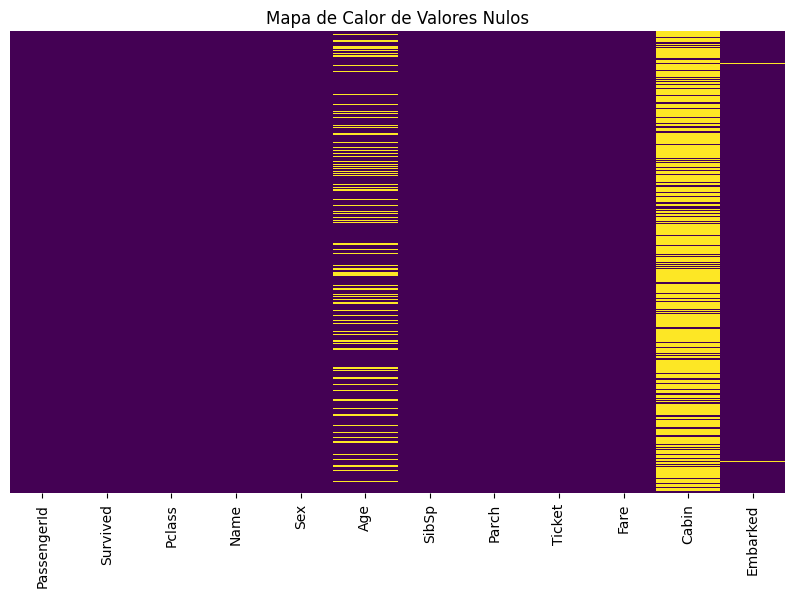

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el mapa de calor de valores nulos
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos')
plt.show()

print(df.isnull().sum())

In [ ]:
# Calcular el porcentaje, redondear y ordenar
porcentaje_nulos = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)

# Mostrar el resultado
print(porcentaje_nulos)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


/tmp/ipykernel_7537/630958637.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos_por_columna.index, y=nulos_por_columna.values, palette='magma')


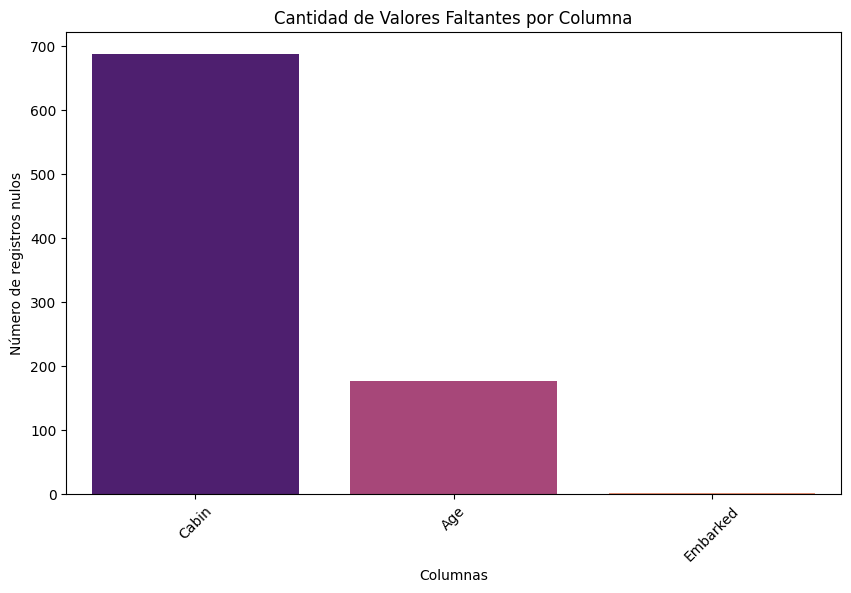

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Calcular la suma de valores nulos por columna
nulos_por_columna = df.isnull().sum()

# 2. Filtrar para mostrar solo las columnas que tienen al menos un nulo (opcional pero recomendado)
nulos_por_columna = nulos_por_columna[nulos_por_columna > 0].sort_values(ascending=False)

# 3. Crear la gráfica de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=nulos_por_columna.index, y=nulos_por_columna.values, palette='magma')

# Configuraciones estéticas
plt.title('Cantidad de Valores Faltantes por Columna')
plt.ylabel('Número de registros nulos')
plt.xlabel('Columnas')
plt.xticks(rotation=45) # Rotar nombres si son largos
plt.show()



In [ ]:

#Nuestro conjunto de entrenamiento tiene muchos datos faltantes en la columna Cabin, y uno que otro en Age
#Dado que no tenemos la gran mayoría de los datos de Cabin nos conviene mejor deshacernos de esta columna. 

#En este caso como la edad tiene valores atipicos en extremos es mejor calcular la mediana y no la media para imputar los valores nulos.

# Calcular la mediana de la columna Age
median_age = df['Age'].median()

# Imputar los valores nulos con la mediana
df['Age'].fillna(median_age, inplace=True)



/tmp/ipykernel_7537/1282404338.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(median_age, inplace=True)


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [ ]:
#hay que imputar los nulos de la columna embarked (como esa columna contiene letras no nos sirven apra hacer cpalculos) necesitamos darles un valor numérico

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.isnull().sum()

#Si vemos ahora los axis de valores nulos, veremos que ya estamos en ceros:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [ ]:

# 1. Contar el total de filas duplicadas
total_duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {total_duplicados}")

# 2. Si quieres ver cuáles son esas filas (si las hubiera):
if total_duplicados > 0:
    display(df[df.duplicated()])

Total de filas duplicadas: 0


In [ ]:
df.drop('Name', axis = 1, inplace = True)
df.drop('Ticket', axis = 1, inplace = True)
df.drop('PassengerId', axis = 1, inplace = True)
df.drop('Cabin', axis = 1, inplace = True)  

In [ ]:
df.to_csv('./data/titanic_clean.csv', index=False)